# Risk Migration Analysis Under Stress Scenarios

## Objective

This notebook analyzes how borrower risk levels evolve under adverse conditions by constructing **risk migration matrices**.

While previous steps focused on:

- baseline risk distribution  
- sensitivity to small changes  
- stress-induced changes in overall risk  

this notebook focuses on **how borrowers transition between risk categories** under stress scenarios.

---

## Why Risk Migration Matters

In credit risk management, it is not sufficient to observe that average risk increases.

A key question is:

> How do borrowers move across risk categories when conditions deteriorate?

Risk migration analysis helps to:

- identify vulnerable borrower segments  
- understand portfolio deterioration dynamics  
- evaluate the stability of the risk framework  
- support scenario-based risk monitoring  

---

## Methodology

We construct migration matrices by comparing borrower risk buckets:

- **Baseline → Mild Stress**
- **Baseline → Severe Stress**

Each matrix shows the proportion of borrowers transitioning from one risk category to another.

Risk buckets are defined as:

- Low  
- Moderate  
- Elevated  
- High  

---

## Interpretation

Rows represent the original (baseline) risk category.  
Columns represent the new category under stress.

Each row sums to 1 and shows how borrowers in a given baseline group redistribute under stress.

This provides a clear view of **risk concentration and upward migration**.

=== Migration Matrix: Baseline → Mild Stress ===
risk_bucket       Low  Moderate  Elevated      High
risk_bucket                                        
Low          0.851667  0.141667  0.006667  0.000000
Moderate     0.000000  0.829268  0.141463  0.029268
Elevated     0.000000  0.000000  0.739583  0.260417
High         0.000000  0.000000  0.000000  1.000000

=== Migration Matrix: Baseline → Severe Stress ===
risk_bucket   Low  Moderate  Elevated      High
risk_bucket                                    
Low          0.64  0.325000  0.028333  0.006667
Moderate     0.00  0.702439  0.243902  0.053659
Elevated     0.00  0.000000  0.552083  0.447917
High         0.00  0.000000  0.000000  1.000000


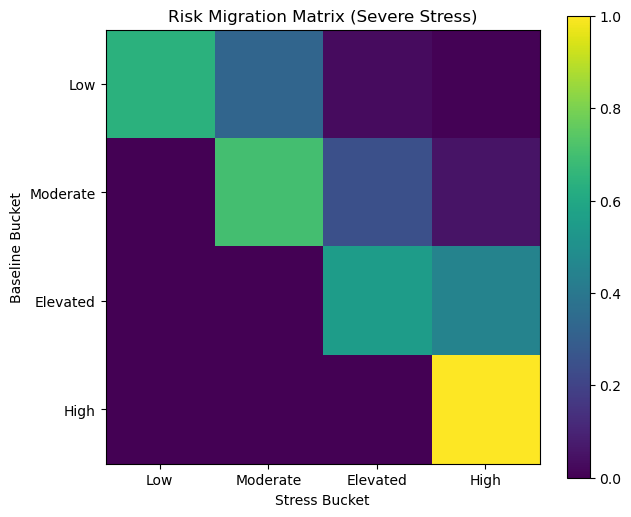

In [1]:
import pandas as pd
import numpy as np

# =====================================
# 1. Load data
# =====================================
file_path = "/Users/quentingao/Desktop/german_credit_data.csv"

df_base_raw = pd.read_csv(file_path)

# Drop index column if exists
if "Unnamed: 0" in df_base_raw.columns:
    df_base_raw = df_base_raw.drop(columns=["Unnamed: 0"])

# =====================================
# 2. Define scoring function (完全独立)
# =====================================
def compute_pseudo_pd(df_raw):
    df = df_raw.copy()

    # -------- categorical mapping --------
    saving_map = {
        "little": 0,
        "moderate": 1,
        "quite rich": 2,
        "rich": 3
    }

    checking_map = {
        "little": 0,
        "moderate": 1,
        "rich": 2
    }

    housing_map = {
        "rent": 0,
        "free": 1,
        "own": 2
    }

    df["saving_score"] = df["Saving accounts"].map(saving_map).fillna(0.5)
    df["checking_score"] = df["Checking account"].map(checking_map).fillna(0.5)
    df["housing_score"] = df["Housing"].map(housing_map)
    df["job_score"] = df["Job"]

    # -------- standardize --------
    for col in ["Age", "Credit amount", "Duration"]:
        df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()

    # -------- risk score --------
    df["risk_score"] = (
        0.60 * df["Credit amount_z"]
        + 0.75 * df["Duration_z"]
        - 0.25 * df["Age_z"]
        - 0.80 * df["saving_score"]
        - 0.60 * df["checking_score"]
        - 0.30 * df["housing_score"]
        - 0.20 * df["job_score"]
    )

    # -------- pseudo PD --------
    df["pseudo_pd"] = 1 / (1 + np.exp(-df["risk_score"]))

    # -------- risk bucket --------
    df["risk_bucket"] = pd.cut(
        df["pseudo_pd"],
        bins=[0, 0.2, 0.4, 0.6, 1],
        labels=["Low", "Moderate", "Elevated", "High"],
        include_lowest=True
    )

    return df

# =====================================
# 3. Baseline
# =====================================
df_base = compute_pseudo_pd(df_base_raw)

# =====================================
# 4. Mild stress
# =====================================
df_mild_raw = pd.read_csv(file_path)

if "Unnamed: 0" in df_mild_raw.columns:
    df_mild_raw = df_mild_raw.drop(columns=["Unnamed: 0"])

df_mild_raw["Credit amount"] *= 1.2
df_mild_raw["Duration"] *= 1.3

df_mild_raw["Saving accounts"] = df_mild_raw["Saving accounts"].replace({
    "rich": "quite rich",
    "quite rich": "moderate",
    "moderate": "little"
})

df_mild_raw["Checking account"] = df_mild_raw["Checking account"].replace({
    "rich": "moderate",
    "moderate": "little"
})

df_mild = compute_pseudo_pd(df_mild_raw)

# =====================================
# 5. Severe stress
# =====================================
df_severe_raw = pd.read_csv(file_path)

if "Unnamed: 0" in df_severe_raw.columns:
    df_severe_raw = df_severe_raw.drop(columns=["Unnamed: 0"])

df_severe_raw["Credit amount"] *= 1.3
df_severe_raw["Duration"] *= 1.5

df_severe_raw["Saving accounts"] = "little"
df_severe_raw["Checking account"] = "little"

df_severe = compute_pseudo_pd(df_severe_raw)

# =====================================
# 6. Migration Matrix
# =====================================

# Mild
migration_mild = pd.crosstab(
    df_base["risk_bucket"],
    df_mild["risk_bucket"],
    normalize="index"
)

print("=== Migration Matrix: Baseline → Mild Stress ===")
print(migration_mild)

# Severe
migration_severe = pd.crosstab(
    df_base["risk_bucket"],
    df_severe["risk_bucket"],
    normalize="index"
)

print("\n=== Migration Matrix: Baseline → Severe Stress ===")
print(migration_severe)

# =====================================
# 7. Optional: visualize severe migration
# =====================================
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.imshow(migration_severe, interpolation='nearest')
plt.title("Risk Migration Matrix (Severe Stress)")
plt.colorbar()

plt.xticks(range(len(migration_severe.columns)), migration_severe.columns)
plt.yticks(range(len(migration_severe.index)), migration_severe.index)

plt.xlabel("Stress Bucket")
plt.ylabel("Baseline Bucket")

plt.show()

# Migration Results Summary

## Mild Stress Scenario

Under the mild stress scenario, the portfolio shows relatively stable behavior, with most borrowers remaining within their original risk categories.

However, there is clear evidence of upward migration:

- Approximately **14% of Low-risk borrowers move into Moderate**
- Around **14% of Moderate borrowers shift to Elevated**
- About **26% of Elevated borrowers transition into High risk**

This indicates that even moderate deterioration in borrower conditions leads to **meaningful risk escalation for already vulnerable groups**, while the safest borrowers remain relatively resilient.

---

## Severe Stress Scenario

Under the severe stress scenario, risk migration becomes significantly more pronounced across all segments.

Key patterns include:

- Only **64% of Low-risk borrowers remain Low**, while:
  - **32.5% move to Moderate**
  - A small but notable share moves directly into Elevated and High risk

- Among Moderate borrowers:
  - Only **70% remain Moderate**
  - Nearly **24% migrate to Elevated**
  - Over **5% move to High risk**

- The most striking shift occurs in the Elevated group:
  - Nearly **45% of Elevated borrowers transition into High risk**

- The High-risk group remains fully persistent, indicating that once borrowers reach this category, they do not revert under stress

---

## Interpretation

The migration matrices reveal a **clear and systematic upward shift in risk distribution** under stress conditions.

Several important insights emerge:

- Risk deterioration is **nonlinear**, accelerating as borrowers move into higher-risk categories  
- Borrowers already in Moderate and Elevated groups are significantly more sensitive to adverse conditions  
- The High-risk segment expands primarily through **inflows from Elevated borrowers**

---

## Conclusion

The results demonstrate that the scoring framework produces **intuitive and economically consistent migration behavior** under stress scenarios.

In particular:

- Risk is not only increasing in magnitude, but also **concentrating in higher-risk segments**
- Portfolio vulnerability becomes significantly more pronounced under severe stress
- The framework effectively captures both **risk escalation and risk concentration dynamics**

---

## Key Takeaway

> Under adverse conditions, risk does not simply increase — it **propagates through the portfolio**, with vulnerable borrowers migrating disproportionately into higher-risk categories.